In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import logging
import os

# Configure logging if you haven't already
# logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# --- DEFINE FILENAME ---
# >>> IMPORTANT: Replace this with the actual filename <<<
abinitio_rock_filename = "eos_mgsio3.dat"
# --- Adjust path if needed ---
try:
    # Assuming it's in ../data/EOS/ relative to where the notebook is run
    base_path = "./"
    filename_abs = os.path.join(base_path, abinitio_rock_filename)
    if not os.path.exists(filename_abs):
         base_path = "./data/EOS/" # Fallback path
         filename_abs = os.path.join(base_path, abinitio_rock_filename)
         if not os.path.exists(filename_abs):
              raise FileNotFoundError(f"Cannot find {abinitio_rock_filename} in expected locations.")

except FileNotFoundError as e:
    print(f"ERROR: {e}")
    # Stop execution or handle appropriately
    raise

# --- Inferred Column Meanings and Units ---
# Based on the snippet and typical ab initio outputs
column_names_abinitio = ['Density_g_cm3', 'Temperature_K', 'InternalEnergy_J_kg', 'Col4_Zero', 'Col5_Zero']

# --- Load the data ---
df_rock_abinitio = None # Initialize
try:
    # Read the file, using whitespace as separator
    df_rock_abinitio = pd.read_csv(filename_abs, sep='\s+', header=None, names=column_names_abinitio,
                                   comment='#', # Assuming lines starting with # are comments
                                   engine='python') # Use python engine for regex separator

    print(f"Successfully read {len(df_rock_abinitio)} rows from {filename_abs}.")
    print(f"  Detected {len(df_rock_abinitio.columns)} columns.")

    if len(df_rock_abinitio.columns) != len(column_names_abinitio):
        print(f"[ERROR] Read {len(df_rock_abinitio.columns)} columns, but expected {len(column_names_abinitio)} based on names.")
        print("  Check the file format and separator.")
        df_rock_abinitio = None
    else:
        # --- Convert columns to numeric ---
        print("\nConverting columns to numeric type...")
        conversion_errors = False
        for col in column_names_abinitio:
            df_rock_abinitio[col] = pd.to_numeric(df_rock_abinitio[col], errors='coerce')
            if df_rock_abinitio[col].isnull().any():
                print(f"  [WARN] Column '{col}' contained non-numeric values (NaN).")
                conversion_errors = True
        if conversion_errors:
             print("  Please check the original data file for non-numeric entries.")

except FileNotFoundError:
    print(f"Error: The file '{filename_abs}' was not found.")
except Exception as e:
    print(f"An error occurred while loading/processing the rock ab initio file: {e}")
    df_rock_abinitio = None # Ensure it's None on error

# Display basic info and head if loaded successfully
if df_rock_abinitio is not None:
    print("\nDataFrame Info:")
    df_rock_abinitio.info()
    print("\nFirst 5 rows:")
    print(df_rock_abinitio.head())
else:
    print("\nCould not load or process ab initio rock EOS data.")

<>:37: SyntaxWarning: invalid escape sequence '\s'
<>:37: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_333888/4025986876.py:37: SyntaxWarning: invalid escape sequence '\s'
  df_rock_abinitio = pd.read_csv(filename_abs, sep='\s+', header=None, names=column_names_abinitio,


Successfully read 4609 rows from ./eos_mgsio3.dat.
  Detected 5 columns.

Converting columns to numeric type...

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4609 entries, 0 to 4608
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Density_g_cm3        4609 non-null   float64
 1   Temperature_K        4609 non-null   float64
 2   InternalEnergy_J_kg  4609 non-null   float64
 3   Col4_Zero            4609 non-null   float64
 4   Col5_Zero            4609 non-null   float64
dtypes: float64(5)
memory usage: 180.2 KB

First 5 rows:
   Density_g_cm3  Temperature_K  InternalEnergy_J_kg  Col4_Zero  Col5_Zero
0       3.431856      11.220183          -174975.734        0.0        0.0
1       3.431856      12.589251          -174710.422        0.0        0.0
2       3.431856      14.125371          -174412.828        0.0        0.0
3       3.431856      15.848925          -174078.859      

In [2]:
if df_rock_abinitio is not None:
    print("\n--- Basic Checks & Statistics (Ab Initio Rock) ---")

    # Check for NaN/Inf values
    nan_inf_check = df_rock_abinitio.isnull().any().any() or np.isinf(df_rock_abinitio.values).any()
    if nan_inf_check:
        print("[WARN] NaN or Inf values detected in the DataFrame.")
        print("Counts per column:")
        print("NaNs:\n", df_rock_abinitio.isnull().sum())
        print("Infs:\n", df_rock_abinitio.apply(lambda x: np.isinf(x).sum()))
    else:
        print("[PASS] No NaN or Inf values detected.")

    # Display descriptive statistics for relevant columns
    print("\nDescriptive Statistics:")
    relevant_cols = ['Density_g_cm3', 'Temperature_K', 'InternalEnergy_J_kg']
    with pd.option_context('display.float_format', '{:.4g}'.format):
        print(df_rock_abinitio[relevant_cols].describe())

    # Check Positivity (where applicable)
    print("\nPositivity Checks:")
    if (df_rock_abinitio['Density_g_cm3'].dropna() <= 0).any(): print("[FAIL] Density <= 0 found.")
    else: print("[PASS] Density > 0.")
    if (df_rock_abinitio['Temperature_K'].dropna() <= 0).any(): print("[FAIL] Temperature <= 0 found.")
    else: print("[PASS] Temperature > 0.")

    # Check if last two columns are zero
    print("\nChecking Placeholder Columns:")
    col4_all_zero = np.allclose(df_rock_abinitio['Col4_Zero'].dropna(), 0, atol=1e-9)
    col5_all_zero = np.allclose(df_rock_abinitio['Col5_Zero'].dropna(), 0, atol=1e-9)
    if col4_all_zero: print("[PASS] Column 4 contains only zero values.")
    else: print("[FAIL] Column 4 contains non-zero values.")
    if col5_all_zero: print("[PASS] Column 5 contains only zero values.")
    else: print("[FAIL] Column 5 contains non-zero values.")

else:
    print("Skipping checks because Ab Initio Rock DataFrame was not loaded.")


--- Basic Checks & Statistics (Ab Initio Rock) ---
[PASS] No NaN or Inf values detected.

Descriptive Statistics:
       Density_g_cm3  Temperature_K  InternalEnergy_J_kg
count           4609           4609                 4609
mean           8.424           2757             1.78e+07
std            3.831           4628            2.041e+07
min            3.432          11.22            -1.75e+05
25%            5.076          70.79            2.007e+06
50%            7.508          446.7            8.672e+06
75%            11.36           3162            2.781e+07
max            16.81      1.995e+04            7.619e+07

Positivity Checks:
[PASS] Density > 0.
[PASS] Temperature > 0.

Checking Placeholder Columns:
[PASS] Column 4 contains only zero values.
[PASS] Column 5 contains only zero values.



--- Plotting Ab Initio Rock EOS Isochores ---
Found 70 unique densities.
Plotting isochores for Rho (g/cm³) approx: [ 3.43  4.22  5.32  6.69  8.42 10.61 13.35 16.81]


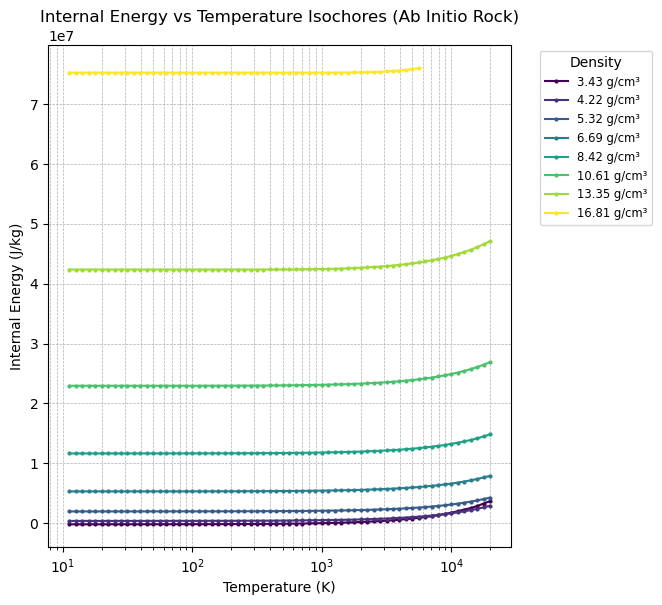

In [3]:
if df_rock_abinitio is not None and not df_rock_abinitio.empty:
    print("\n--- Plotting Ab Initio Rock EOS Isochores ---")
    # Data is structured by Density, so we plot along lines of constant Density (isochores)

    # Identify unique densities
    unique_rhos = sorted(df_rock_abinitio['Density_g_cm3'].dropna().unique())
    print(f"Found {len(unique_rhos)} unique densities.")

    # Select a subset of densities to plot
    num_isochores_to_plot = 8
    if len(unique_rhos) > num_isochores_to_plot:
        indices = np.linspace(0, len(unique_rhos) - 1, num_isochores_to_plot, dtype=int)
        rhos_to_plot = [unique_rhos[i] for i in indices]
    else:
        rhos_to_plot = unique_rhos

    print(f"Plotting isochores for Rho (g/cm³) approx: {np.round(rhos_to_plot, 2)}")

    # Define bounds for filtering plots (adjust if needed)
    T_min, T_max = 1e-1, 1e8 # K
    rho_min, rho_max = 1e-9, 1e2 # g/cm3
    U_min, U_max = -1e7, 1e8 # J/kg (Adjust based on describe())

    # Create plot
    plt.figure(figsize=(8, 6))
    colors = plt.cm.viridis(np.linspace(0, 1, len(rhos_to_plot)))

    plot_successful = False
    for i, rho in enumerate(rhos_to_plot):
        # Select data for the current isochore
        isochore_data = df_rock_abinitio[np.isclose(df_rock_abinitio['Density_g_cm3'], rho)].copy()

        if isochore_data.empty: continue

        # Filter this specific isochore
        T_filt = isochore_data['Temperature_K']
        rho_filt = isochore_data['Density_g_cm3'] # Should be constant here
        U_filt = isochore_data['InternalEnergy_J_kg']

        mask = (
            (T_filt > T_min) & (T_filt < T_max) & (rho_filt > rho_min) & (rho_filt < rho_max) &
            (U_filt > U_min) & (U_filt < U_max) &
            (~np.isnan(T_filt)) & (~np.isinf(T_filt)) & (~np.isnan(rho_filt)) & (~np.isinf(rho_filt)) &
            (~np.isnan(U_filt)) & (~np.isinf(U_filt))
        )
        isochore_filtered = isochore_data[mask]

        if isochore_filtered.empty: continue

        plot_successful = True
        isochore_filtered = isochore_filtered.sort_values(by='Temperature_K') # Sort by Temp for plotting
        label = f'{rho:.2f} g/cm³'
        color = colors[i]

        # Plot U vs T
        plt.plot(isochore_filtered['Temperature_K'], isochore_filtered['InternalEnergy_J_kg'],
                 marker='.', markersize=4, linestyle='-', color=color, label=label)

    if plot_successful:
        plt.xlabel("Temperature (K)")
        plt.ylabel("Internal Energy (J/kg)")
        plt.title("Internal Energy vs Temperature Isochores (Ab Initio Rock)")
        plt.xscale('log') # Temperature often spans orders of magnitude
        # plt.yscale('log') # Decide based on energy range
        plt.legend(title="Density", fontsize='small', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, which='both', linestyle='--', linewidth=0.5)
        plt.tight_layout(rect=[0, 0, 0.85, 1])
        plt.show()
    else:
        print("\nNo valid isochores found to plot after filtering.")

else:
    print("Skipping plots because Ab Initio Rock DataFrame was not loaded.")

/tmp/ipykernel_333888/3332105854.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Density", fontsize='small', bbox_to_anchor=(1.05, 1), loc='upper left')


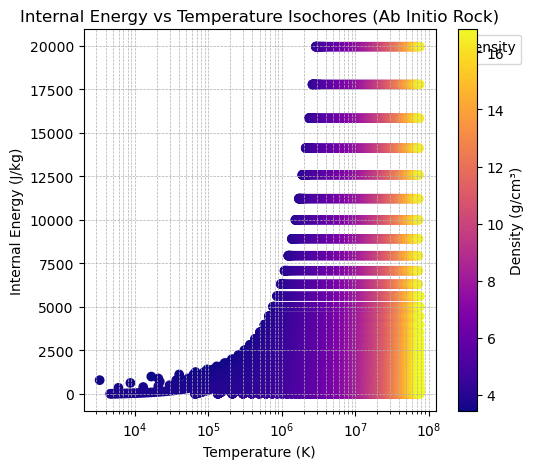

In [8]:
plt.scatter(df_rock_abinitio['InternalEnergy_J_kg'], df_rock_abinitio['Temperature_K'],c = df_rock_abinitio['Density_g_cm3'], cmap='plasma')
plt.colorbar(label='Density (g/cm³)')
plt.xlabel("Temperature (K)")
plt.ylabel("Internal Energy (J/kg)")
plt.title("Internal Energy vs Temperature Isochores (Ab Initio Rock)")
plt.xscale('log') # Temperature often spans orders of magnitude
# plt.yscale('log') # Decide based on energy range
plt.legend(title="Density", fontsize='small', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()